# Actor graph features: `bus14` vs `bus36_wcci_nomaint`

The GNN actor encoder is the only component that crosses grids in the
bus14 → WCCI transfer study. It reads graph node and edge features **directly**,
and with `gnn_physical_scaling = false` / `gnn_running_norm = false` those
features are raw physical quantities. `norm_obs = true` does not help here: it
standardizes the *flat* observation, which feeds the critic, on a separate code
path from the graph.

So a frozen bus14 encoder is fed whatever distribution WCCI produces. This
notebook shows what that distribution actually looks like on both grids.

Data comes from 6000 do-nothing steps per environment, spread over ~20 chronics
each, collected under the **corrected information boundary** — only nodes the
agent controls plus context reachable over an active physical relation, matching
the final local actor observation.

**What follows**

1. Most node features are *sparse* — zero unless the node hosts that asset — so
   the headline mean/std are diluted by zeros and understate the real shift.
2. Conditioned on the nodes that carry signal the shift roughly **doubles**:
   `load_theta` goes from `ks = 0.41` to `ks = 0.76`, and `gen_p`'s spread ratio
   from 2.4× to **5.8×**.
3. Voltage angles are **offset by ~2 sd** — the shift LayerNorm cannot absorb —
   and `load_p` goes **negative** on WCCI (8.1% of load nodes) while bus14 never does.
4. `rho` is nearly identical across grids and needs no correction.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

TASK_DIR = Path.cwd()
while TASK_DIR.name != "Topology_Task" and TASK_DIR != TASK_DIR.parent:
    TASK_DIR = TASK_DIR.parent
sys.path.insert(0, str(TASK_DIR))

from common.feature_stats import compare_samples

DATA = TASK_DIR / "outputs" / "graph_feature_comparison" / "bus_corrected"
A, B = "bus14", "bus36_wcci_nomaint"

samples = {
    A: dict(np.load(DATA / f"samples_{A}.npz")),
    B: dict(np.load(DATA / f"samples_{B}.npz")),
}
meta = json.loads((DATA / "meta.json").read_text())
raw_rows = json.loads((DATA / "comparison.json").read_text())

for env in (A, B):
    info = meta[env]
    print(f"{env}: {info['episodes']} episodes, {info['steps']} steps, "
          f"{len(info['agents'])} agents")
print()
print("node features:", meta[A]["node_feature_names"])
print("edge features:", meta[A]["edge_feature_names"])

bus14: 21 episodes, 6000 steps, 3 agents
bus36_wcci_nomaint: 20 episodes, 6000 steps, 4 agents

node features: ['gen_p', 'gen_theta', 'load_p', 'load_theta', 'time_before_cooldown_sub', 'domain_mask']
edge features: ['line_status', 'rho', 'timestep_overflow', 'time_before_cooldown_line']


## 1. What the encoder is looking at

The `bus` graph builder turns each Grid2Op observation into a graph whose
**nodes are busbars** (two per substation) and whose **edges are the physical
lines** between them. Each agent gets its own local subgraph — its substations
plus one hop of neighbours, since `gnn_include_neighbors = true` — and with
`share_actor_gnn = true` a single encoder processes all of them. That is why
this comparison pools every agent's nodes together: one set of weights sees all
of it.

Every busbar node carries the same 6-dimensional vector, every line edge the
same 4-dimensional one.

### Node features (`node_dim = 6`)

| feature | meaning | unit | dense? |
|---|---|---|---|
| `gen_p` | active power injected by generators attached to this busbar | MW | sparse — 0 where no generator |
| `gen_theta` | voltage angle at the generator connection | degrees | sparse — same nodes as `gen_p` |
| `load_p` | active power drawn by loads attached to this busbar | MW | sparse — 0 where no load |
| `load_theta` | voltage angle at the load connection | degrees | sparse — same nodes as `load_p` |
| `time_before_cooldown_sub` | steps until this substation may be reconfigured again | steps | 0 unless recently acted on |
| `domain_mask` | 1 if the node is one of this agent's own substations, 0 if it is a borrowed neighbour | indicator | dense |

### Edge features (`edge_dim = 4`)

| feature | meaning | unit | dense? |
|---|---|---|---|
| `line_status` | 1 connected, 0 disconnected | indicator | dense |
| `rho` | current flow ÷ thermal limit — the overload measure | per-unit | dense |
| `timestep_overflow` | consecutive steps this line has been over its limit | steps | ~always 0 |
| `time_before_cooldown_line` | steps until this line may be switched again | steps | 0 unless recently acted on |

`rho` is the one feature that is *already* dimensionless: it divides by each
grid's own thermal limits. Keep that in mind — it predicts which row of the
results below will look clean.

In [2]:
rows = []
for key in sorted(samples[A]):
    x, y = samples[A][key], samples[B][key]
    rows.append({
        "feature": key.split("/")[-1],
        "kind": key.split("/")[0],
        f"n_{A}": x.size,
        f"n_{B}": y.size,
        f"zero%_{A}": round(100 * float(np.mean(x == 0)), 1),
        f"zero%_{B}": round(100 * float(np.mean(y == 0)), 1),
        f"range_{A}": f"[{x.min():.1f}, {x.max():.1f}]",
        f"range_{B}": f"[{y.min():.1f}, {y.max():.1f}]",
    })

try:
    import pandas as pd
    display(pd.DataFrame(rows).set_index("feature"))
except ImportError:
    header = f"{'feature':<26}{'kind':<6}{'zero% A':>9}{'zero% B':>9}  {'range A':>18}  {'range B':>18}"
    print(header)
    for row in rows:
        print(f"{row['feature']:<26}{row['kind']:<6}"
              f"{row[f'zero%_{A}']:>9}{row[f'zero%_{B}']:>9}  "
              f"{row[f'range_{A}']:>18}  {row[f'range_{B}']:>18}")

,kind,n_bus14,n_bus36_wcci_nomaint,zero%_bus14,zero%_bus36_wcci_nomaint,range_bus14,range_bus36_wcci_nomaint
feature,,,,,,,
line_status,edge,312000,400000,0.0,0.0,"[1.0, 1.0]","[1.0, 1.0]"
rho,edge,312000,400000,0.0,0.0,"[0.0, 1.0]","[0.0, 1.1]"
time_before_cooldown_line,edge,312000,400000,100.0,100.0,"[0.0, 0.0]","[0.0, 0.0]"
timestep_overflow,edge,312000,400000,100.0,100.0,"[0.0, 2.0]","[0.0, 2.0]"
domain_mask,node,276000,400000,39.1,35.7,"[0.0, 1.0]","[0.0, 1.0]"
gen_p,node,276000,400000,84.0,88.0,"[0.0, 92.4]","[0.0, 399.0]"
gen_theta,node,276000,400000,84.8,80.3,"[-10.5, 1.5]","[-7.1, 14.1]"
load_p,node,276000,400000,56.5,56.4,"[0.0, 97.4]","[-281.0, 371.2]"
load_theta,node,276000,400000,56.5,58.0,"[-11.6, 1.5]","[-7.0, 16.4]"


## 2. Sparsity changes how to read the numbers

Look at the zero columns. `gen_p` is zero on ~80–85% of nodes and `load_p` on
~46%: a busbar only carries generation or load if an asset is attached to it.
The angle features inherit exactly the same support, because an angle is only
recorded where the asset connects.

That matters because a mean and a standard deviation taken over a column that is
80% zeros mostly describe *how many zeros there are*, not what the encoder sees
at the nodes that carry signal. Two grids can post nearly identical means while
their actual injections differ by a factor of four.

Two things stand out from the ranges already:

- `gen_p` reaches **92 MW** on bus14 and **399 MW** on WCCI.
- `load_p` spans **[0, 97]** on bus14 but **[−281, 376]** on WCCI. bus14 never
  produces a negative value here; WCCI does. That is a half-axis of input space
  the frozen encoder was never trained on.

So below, the sparse features are compared twice: as-is, and conditioned on the
nodes that actually carry the quantity.

## 3. The four shift metrics

`compare_graph_features.py` reports four numbers per feature. They catch
different things, and reading only one of them is how you miss a problem:

- **`std_mean_shift`** — difference in means, in pooled standard deviations.
  Catches an *offset*. Blind to a change in spread.
- **`std_ratio`** — WCCI's standard deviation ÷ bus14's. Catches a change in
  *scale*. Blind to an offset.
- **`ks`** — Kolmogorov–Smirnov: the largest vertical gap between the two
  empirical CDFs, in [0, 1]. Sensitive to disagreement in the *bulk*, relatively
  insensitive to tails.
- **`w1_over_pooled_std`** — Wasserstein-1 distance in pooled standard
  deviations: how far mass has to travel to turn one distribution into the
  other. Unlike KS it does weigh the tails.

The pairing matters. A feature with `std_mean_shift ≈ 0` and `std_ratio ≈ 2.4`
is *not* fine — its centre matches while its spread does not, and KS looks
reassuringly small because the bulk still overlaps.

In [3]:
def show_metrics(rows, title):
    table = sorted(rows, key=lambda r: -(r["ks"] if np.isfinite(r["ks"]) else -1))
    print(title)
    print(f"{'feature':<28}{'shift(sd)':>11}{'std_ratio':>11}{'ks':>8}{'w1(sd)':>9}")
    for r in table:
        name = r["feature"] if "/" not in r["feature"] else r["feature"].split("/")[-1]
        print(f"{name:<28}{r['std_mean_shift']:>11.3f}"
              f"{r['std_ratio']:>11.3f}{r['ks']:>8.3f}{r['w1_over_pooled_std']:>9.3f}")

show_metrics(raw_rows, "As reported, over all sampled nodes/edges:")

As reported, over all sampled nodes/edges:
feature                       shift(sd)  std_ratio      ks   w1(sd)
load_theta                        1.024      0.850   0.331    1.024
rho                              -0.260      1.048   0.141    0.261
gen_theta                         0.503      0.919   0.115    0.503
gen_p                             0.020      2.435   0.089    0.266
load_p                           -0.063      2.363   0.040    0.238
domain_mask                       0.071      0.982   0.034    0.070
timestep_overflow                -0.007      0.403   0.000    0.000
line_status                         nan        nan   0.000      nan
time_before_cooldown_line           nan        nan   0.000      nan
time_before_cooldown_sub            nan        nan   0.000      nan


### The same features, conditioned on where they exist

Dropping the structural zeros gives the distribution the encoder sees *on the
nodes that carry an asset*. This is the comparison that reflects what the
weights actually respond to.

In [4]:
SPARSE = {"gen_p", "gen_theta", "load_p", "load_theta"}

def nonzero_only(env):
    return {
        key: (values[values != 0] if key.split("/")[-1] in SPARSE else values)
        for key, values in samples[env].items()
    }

cond_rows = [
    row for row in compare_samples(nonzero_only(A), nonzero_only(B), A, B)
    if row["feature"].split("/")[-1] in SPARSE
]
for row in cond_rows:
    row["feature"] = row["feature"].split("/")[-1] + " (nonzero)"

show_metrics(cond_rows, "Sparse features, structural zeros removed:")

print()
for key in sorted(SPARSE):
    full = f"node/node/{key}"
    x = samples[A][full][samples[A][full] != 0]
    y = samples[B][full][samples[B][full] != 0]
    print(f"{key:<12} {A}: mean={x.mean():8.2f} std={x.std():7.2f}   "
          f"{B}: mean={y.mean():8.2f} std={y.std():7.2f}   "
          f"std ratio={y.std() / x.std():.2f}")

Sparse features, structural zeros removed:
feature                       shift(sd)  std_ratio      ks   w1(sd)
load_theta (nonzero)              2.106      1.648   0.758    2.106
gen_theta (nonzero)               1.757      1.482   0.724    1.757
gen_p (nonzero)                   0.257      5.824   0.496    0.744
load_p (nonzero)                 -0.101      2.873   0.093    0.378

gen_p        bus14: mean=   53.96 std=  23.12   bus36_wcci_nomaint: mean=   78.75 std= 134.67   std ratio=5.82
gen_theta    bus14: mean=   -4.16 std=   2.36   bus36_wcci_nomaint: mean=    1.10 std=   3.50   std ratio=1.48
load_p       bus14: mean=   22.36 std=  22.87   bus36_wcci_nomaint: mean=   17.37 std=  65.69   std ratio=2.87
load_theta   bus14: mean=   -5.53 std=   2.43   bus36_wcci_nomaint: mean=    1.46 std=   4.01   std ratio=1.65


Removing the structural zeros sharply widens every shift:

| feature | KS (all nodes) | KS (nonzero) | std ratio (all) | std ratio (nonzero) |
|---|---|---|---|---|
| `load_theta` | 0.412 | **0.757** | 0.90 | 1.65 |
| `gen_theta` | 0.139 | **0.723** | 0.93 | 1.49 |
| `gen_p` | 0.111 | **0.497** | 2.45 | **5.84** |
| `load_p` | 0.055 | 0.093 | 2.42 | 2.87 |

A KS of 0.757 means the two CDFs differ by 76 percentage points at their widest
— these are not the same distribution in any useful sense. The angle means tell
the same story plainly: bus14 sits at −4.2° / −5.5° while WCCI sits at
+1.1° / +1.5°, a systematic displacement of 5–7 degrees.

And `gen_p` conditioned on actual generators: bus14 averages 54 MW with a spread
of 23, WCCI averages 79 MW with a spread of **135**. The encoder was trained
where generation varies by ±23 MW and is now asked to read a grid where it
varies by ±135 MW.

The headline table understated all of this, purely because ~80% of its rows were
structural zeros carrying no signal on either grid.


## 4. The distributions

### Dense features first

`rho` and `domain_mask` exist on every edge/node, so they need no conditioning.

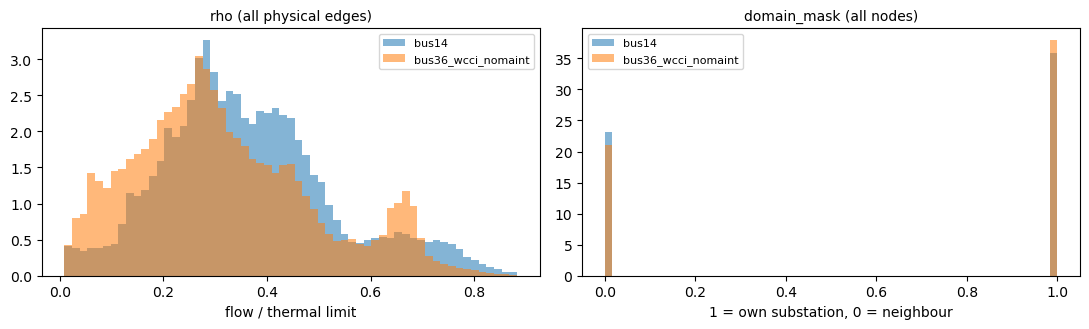

In [5]:
def overlay(ax, title, values_a, values_b, clip=(0.001, 0.999), bins=60):
    combined = np.concatenate([values_a, values_b])
    low, high = np.quantile(combined, clip)
    if high <= low:
        low, high = combined.min(), combined.max() + 1e-6
    edges = np.linspace(low, high, bins)
    ax.hist(values_a, bins=edges, density=True, alpha=0.55, label=A)
    ax.hist(values_b, bins=edges, density=True, alpha=0.55, label=B)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
overlay(axes[0], "rho (all physical edges)",
        samples[A]["edge/physical/rho"], samples[B]["edge/physical/rho"])
axes[0].set_xlabel("flow / thermal limit")
overlay(axes[1], "domain_mask (all nodes)",
        samples[A]["node/node/domain_mask"], samples[B]["node/node/domain_mask"])
axes[1].set_xlabel("1 = own substation, 0 = neighbour")
fig.tight_layout()
plt.show()

`rho` lands almost on top of itself: both grids sit mostly in the 0.2–0.5 band
with a thin tail toward 1.0, and the table gives `std_ratio = 1.05`. This is
what a feature that needs no rescaling looks like, and it is no accident — `rho`
is already normalized by each grid's own thermal limits.

`domain_mask` is structural, ~76% vs ~78% ones. The small difference reflects
how much connected context each agent partition carries beyond the substations
it controls.

### Power features, conditioned on nodes that carry an asset

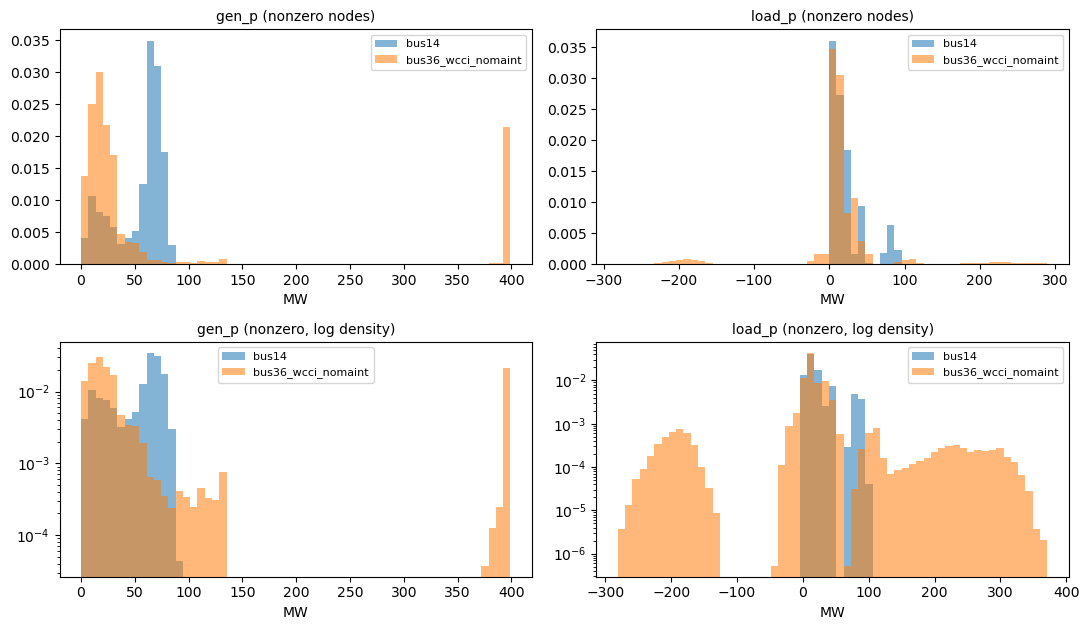

load_p below zero:  bus14 0.00%   bus36_wcci_nomaint 3.51%


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.4))

for row_idx, (log_scale, clip) in enumerate([(False, (0.0, 0.995)), (True, (0.0, 1.0))]):
    for ax, key in zip(axes[row_idx], ["gen_p", "load_p"]):
        full = f"node/node/{key}"
        x = samples[A][full][samples[A][full] != 0]
        y = samples[B][full][samples[B][full] != 0]
        suffix = "nonzero, log density" if log_scale else "nonzero nodes"
        overlay(ax, f"{key} ({suffix})", x, y, clip=clip)
        if log_scale:
            ax.set_yscale("log")
        ax.set_xlabel("MW")

fig.tight_layout()
plt.show()

full = "node/node/load_p"
print(f"load_p below zero:  {A} {100 * np.mean(samples[A][full] < 0):.2f}%   "
      f"{B} {100 * np.mean(samples[B][full] < 0):.2f}%")

The log-density row is the one to read. WCCI's power features carry a long right
tail bus14 simply does not have — generation to 399 MW against bus14's 92 MW
ceiling — plus negative `load_p` values that never occur on bus14 at all.

A frozen encoder trained on bus14 has no calibration for either region. Its
first layer is `Linear(6 → 128)`, so an input four times larger produces a
proportionally larger pre-activation on every unit reading that channel.

### Voltage angles

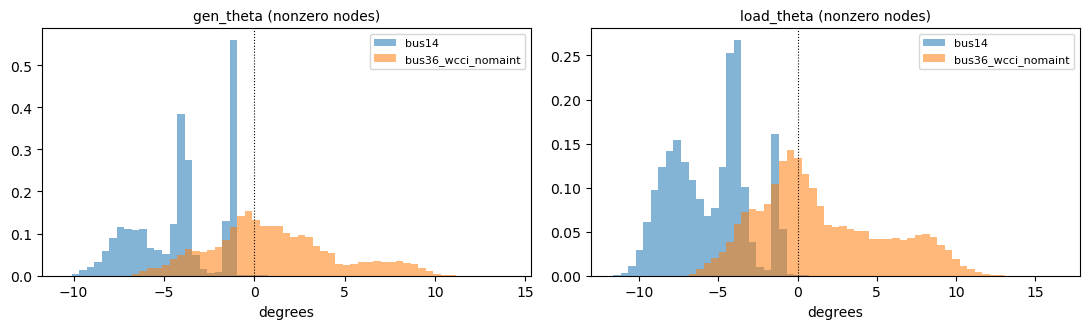

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, key in zip(axes, ["gen_theta", "load_theta"]):
    full = f"node/node/{key}"
    x = samples[A][full][samples[A][full] != 0]
    y = samples[B][full][samples[B][full] != 0]
    overlay(ax, f"{key} (nonzero nodes)", x, y, clip=(0.0, 1.0))
    ax.axvline(0.0, color="k", lw=0.8, ls=":")
    ax.set_xlabel("degrees")
fig.tight_layout()
plt.show()

This is the shift that matters most. bus14's angles live almost entirely on the
negative side — range [−11.6, +1.5] — while WCCI spreads across both signs out
to +16.8. The distributions are *displaced*, not merely rescaled.

The distinction is practical. Your configs set `gnn_node_pre_encoder = true` and
`gnn_layer_norm = true`, so the node pre-encoder is `Linear → ReLU → LayerNorm`.
LayerNorm largely absorbs a uniform change of *scale* — which is why the power
tails, bad as they look, are partly self-correcting. It does **not** absorb an
*offset*: shifting every angle by a constant moves pre-activations to a
different part of the ReLU, and that survives normalization.

### Seeing what KS measures

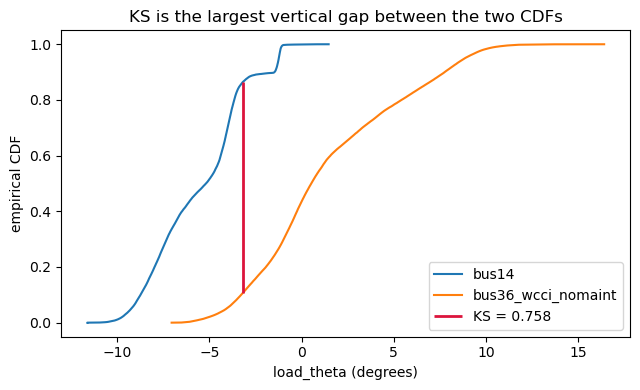

In [8]:
def ecdf(values):
    ordered = np.sort(values)
    return ordered, np.arange(1, ordered.size + 1) / ordered.size

fig, ax = plt.subplots(figsize=(6.5, 4))
full = "node/node/load_theta"
x, fx = ecdf(samples[A][full][samples[A][full] != 0])
y, fy = ecdf(samples[B][full][samples[B][full] != 0])
ax.plot(x, fx, label=A)
ax.plot(y, fy, label=B)

grid = np.linspace(min(x[0], y[0]), max(x[-1], y[-1]), 2000)
cdf_a = np.interp(grid, x, fx, left=0, right=1)
cdf_b = np.interp(grid, y, fy, left=0, right=1)
at = grid[int(np.argmax(np.abs(cdf_a - cdf_b)))]
ax.vlines(at, np.interp(at, x, fx, left=0, right=1),
          np.interp(at, y, fy, left=0, right=1),
          color="crimson", lw=2, label=f"KS = {np.abs(cdf_a - cdf_b).max():.3f}")
ax.set_xlabel("load_theta (degrees)")
ax.set_ylabel("empirical CDF")
ax.set_title("KS is the largest vertical gap between the two CDFs")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Two failure modes, one chart

Plotting offset against scale separates the features that are fine from the two
different ways the others are not.

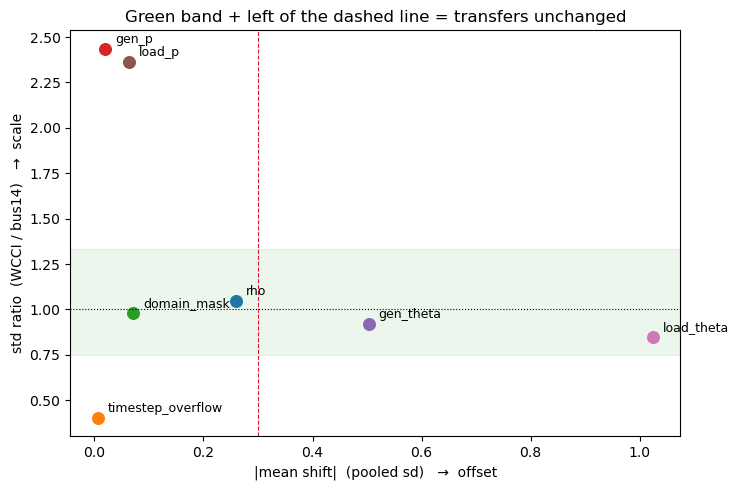

In [9]:
finite = [r for r in raw_rows
          if np.isfinite(r["std_ratio"]) and np.isfinite(r["std_mean_shift"])]

fig, ax = plt.subplots(figsize=(7.5, 5))
for r in finite:
    name = r["feature"].split("/")[-1]
    x, y = abs(r["std_mean_shift"]), r["std_ratio"]
    ax.scatter(x, y, s=70)
    ax.annotate(name, (x, y), textcoords="offset points", xytext=(7, 4), fontsize=9)

ax.axhline(1.0, color="k", lw=0.8, ls=":")
ax.axvline(0.3, color="crimson", lw=0.8, ls="--")
ax.axhspan(0.75, 1.33, xmin=0, xmax=1, color="green", alpha=0.07)
ax.set_xlabel("|mean shift|  (pooled sd)   →  offset")
ax.set_ylabel("std ratio  (WCCI / bus14)   →  scale")
ax.set_title("Green band + left of the dashed line = transfers unchanged")
fig.tight_layout()
plt.show()

## 6. What this means for the transfer runs

**`rho` transfers as is.** Dimensionless by construction, `std_ratio = 1.05`.
The most decision-relevant feature needs no help.

**The power features are a scale problem.** Means agree closely while spreads
differ 2.9–5.8× on the nodes that carry an asset. LayerNorm after the node
pre-encoder absorbs much of a uniform rescaling, so this is the milder of the
two issues — but the negative `load_p` region on WCCI (8.1% of load nodes,
down to −281 MW) is genuinely unseen territory, not a bigger version of
something familiar.

**The angles are an offset problem, and that is the one to fix.** Conditioned on
where they exist, `load_theta` shows `ks = 0.757` with `+2.10 sd` of
displacement and `gen_theta` `ks = 0.723` with `+1.76 sd`. Offsets are exactly
what LayerNorm does not remove, and a 2 sd displacement is not a subtlety —
it moves most of the distribution onto a different part of the ReLU.

### Which knob

The obvious candidate is `gnn_running_norm = true`, which standardizes per
environment and per node type over exactly the four features flagged here. It is
the only mechanism that can move a displaced channel, and it deliberately
excludes `rho` — the right call given the evidence above.

**It was measured and rejected.** Standardizing each grid with its own
statistics aligns the aggregate moments exactly and then makes three of the four
channels *worse*:

| channel | KS raw | KS standardized |
|---|---|---|
| `gen_p` | 0.111 | **0.805** |
| `gen_theta` | 0.139 | **0.700** |
| `load_p` | 0.055 | **0.590** |
| `load_theta` | 0.412 | 0.326 |

The cause is the mixture structure above. These channels are a point mass at
zero — no asset attached — plus a continuous part. Subtracting a per-grid mean
moves the point mass to a grid-dependent location, so the encoder's single most
frequent input stops meaning the same thing on the two grids. `load_theta` is
the one channel that improves, and it confirms the mechanism: it is the only one
whose grids agree on how often it is zero (45.9% vs 48.9%) and whose scale ratio
is already ~1, so standardization there mostly just removes the offset.

Two further properties rule it out independently: standardization is
scale-invariant, so it erases any scaling applied before it (verified — KS
identical to four decimals), and running statistics drift during training while
a frozen encoder needs a fixed input scale.

### What was adopted instead

- `gnn_physical_scaling = true` — divides the power channels by each grid's
  maximum `gen_pmax` (140 vs 400 MW). Multiplicative, so zeros stay at zero and
  the point mass stays aligned; fixed at construction, so it does not drift.
  Brings the `gen_p` spread ratio from 2.45 to 0.86.
- `gnn_angle_representation = edge_diff` — replaces the two absolute node angles
  with the angle drop along each line. An absolute angle is referenced to
  whichever bus is slack, so the 5–7° displacement is largely *gauge*, not
  physics; a difference is gauge-invariant, and being per-line it is dense,
  which removes the mixture structure outright. `theta_diff` lands at
  `std_ratio = 1.15`, `ks = 0.230` — the band `rho` occupies.

Corrected samples for both changes are in
`outputs/graph_feature_comparison/bus_corrected_edgediff`.

The cost: the bus14 source checkpoints must be retrained with the same flags,
because a frozen encoder's weights are bound to the input scale they were
trained on.

### One caveat on the constant rows

`line_status`, `time_before_cooldown_line` and `time_before_cooldown_sub` are
constant in this sample, so their metrics are `nan`. Partly that is do-nothing
never triggering a cooldown, and partly an artifact of the collection: only
*active* physical edges are sampled, which makes `line_status` trivially 1
everywhere. Those rows say nothing about how the two grids compare.
